# Demo example: Parabolic Function 1
This notebook demonstrates the use of the iCE algorithms on a simple parabolic function.

Density model includes: Single Gaussian (SG), Kernel Density Estimation (KDE), Nonparametric Gaussian Mixture (NGM).

Stopping criteria includes: fixed stopping criteria, budget-informed stopping criteria.

In [1]:
from src.utils import *
from src.iceais import *
np.random.seed(0)

## Problem initialization

In [2]:
""" 1. Define the problem. """
# The input density function is a standard multivariate normal distribution.
input_density = GaussianMixtureDensity(p=2, K=1)
# set limit state function
limit_state_func = parabolic_1
# true failure probability
pf_true = 0.003016516

## iCE-SG with fixed stopping criteria

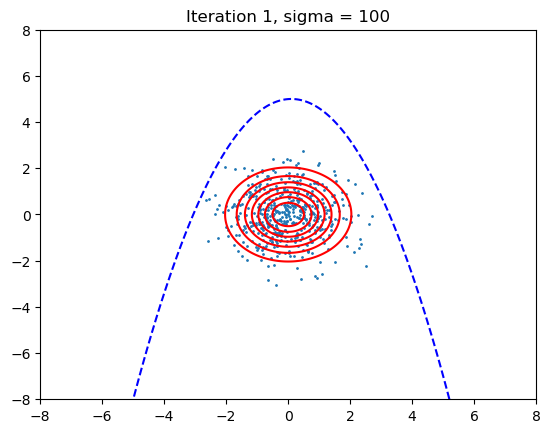

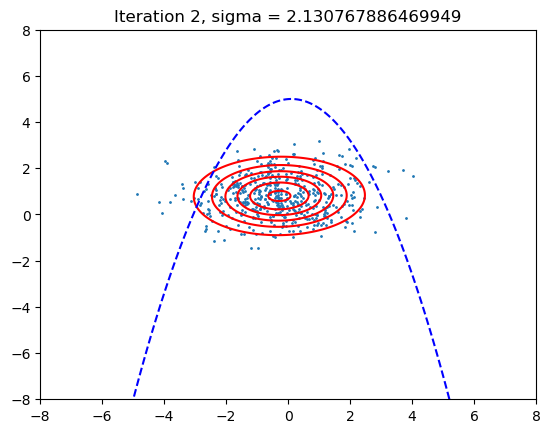

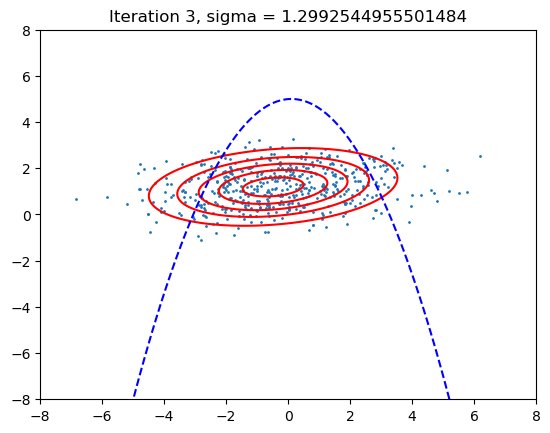

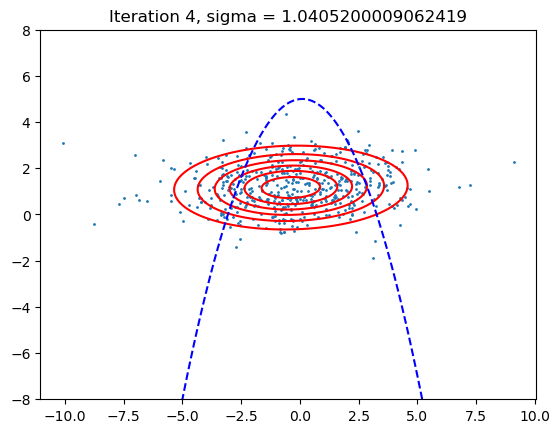

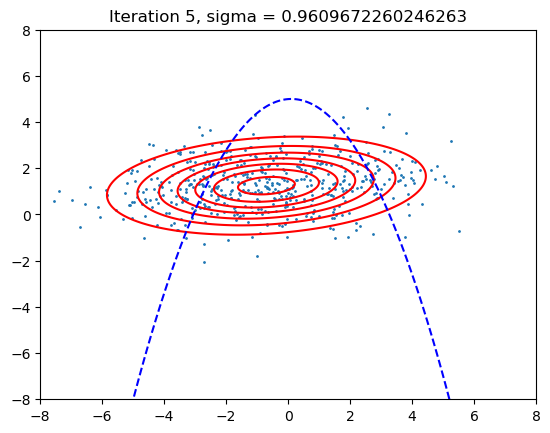

Converged after 5 iterations.
Failure probability estimated by iCE-SG: 0.0029894185611958205
Relative error: -0.00898302505412848


In [3]:
""" 2.1 Solve the problem with iCE-SG and fixed stopping criteria. """
ice_sg = ImprovedCEAISSingleGaussian(limit_state_func=limit_state_func, input_density=input_density)
# samples per level is set to 500, delta_target is set to 1.5, the training process is plotted.
ice_sg.fit(max_iter=100, samples_per_level=500, delta_target=1.5, plot_process=True)
# predict the failure probability with N=3000 samples.
pf_sg = ice_sg.predict(N=3000)
print(f"Failure probability estimated by iCE-SG: {pf_sg}")
print(f"Relative error: {(pf_sg - pf_true) / pf_true}")

## iCE-KDE with fixed stopping criteria

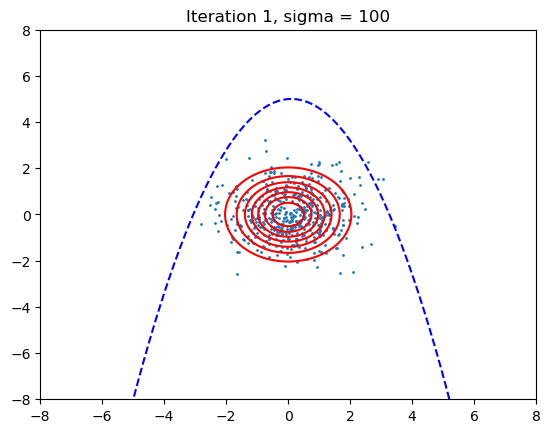

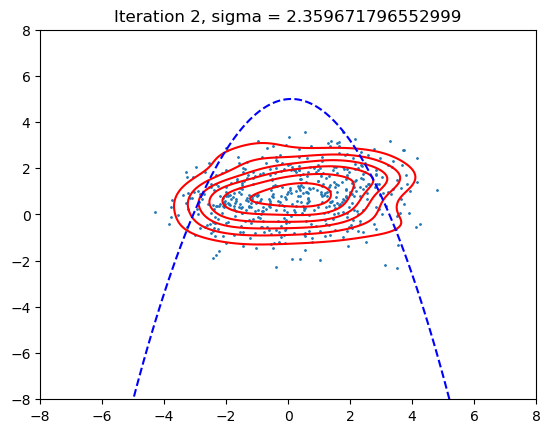

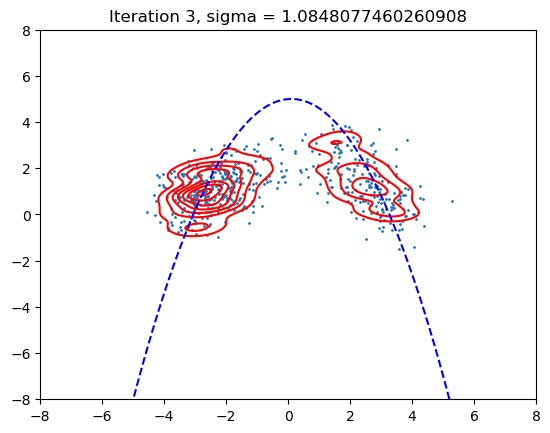

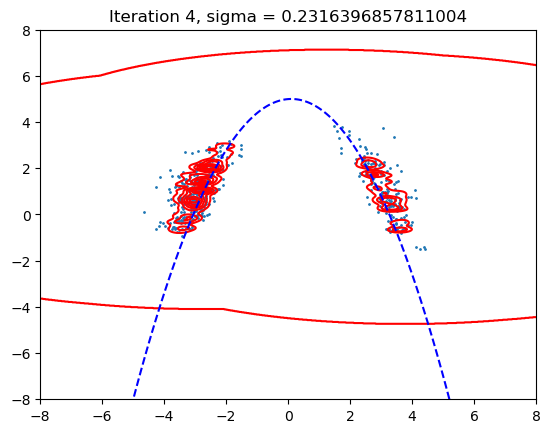

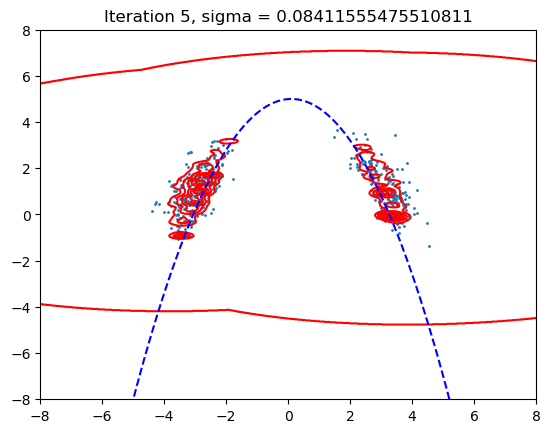

Converged after 5 iterations.
Failure probability estimated by iCE-KDE: 0.003036490164701168
Relative error: 0.006621600780890248


In [4]:
""" 2.2 Solve the problem with iCE-KDE and fixed stopping criteria. """
ice_kde = ImprovedCEAISKernelDensityEstimation(limit_state_func=limit_state_func, input_density=input_density)
# for KDE, delta_target is set to 0.6 since it is achievable.
ice_kde.fit(max_iter=100, samples_per_level=500, delta_target=0.6, plot_process=True)
# predict the failure probability with N=3000 samples.
pf_kde = ice_kde.predict(N=3000)
print(f"Failure probability estimated by iCE-KDE: {pf_kde}")
print(f"Relative error: {(pf_kde - pf_true) / pf_true}")

## iCE-NGM with fixed stopping criteria

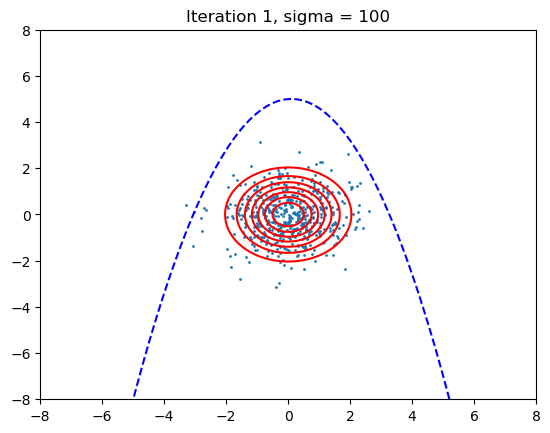

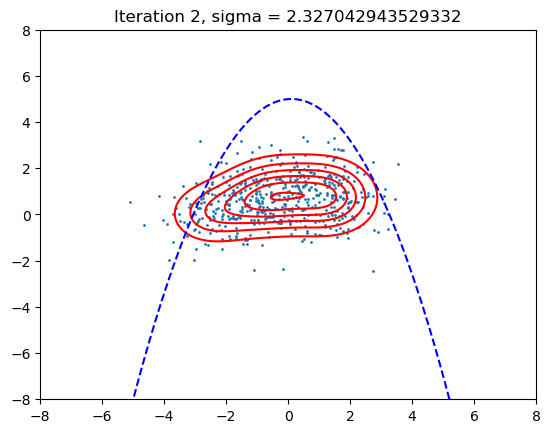

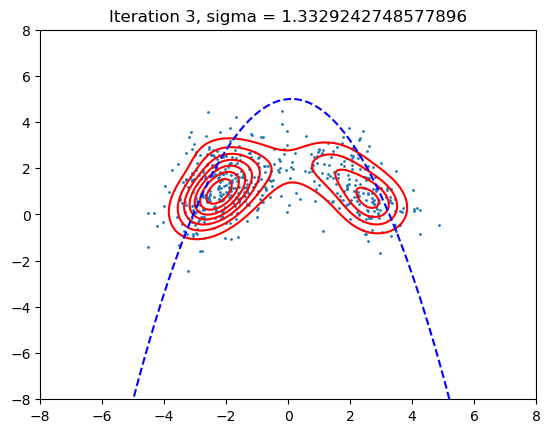

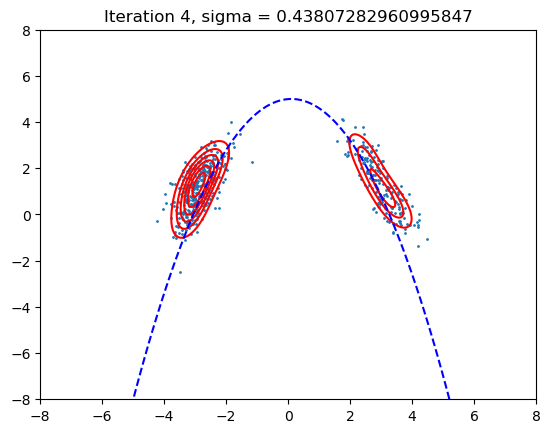

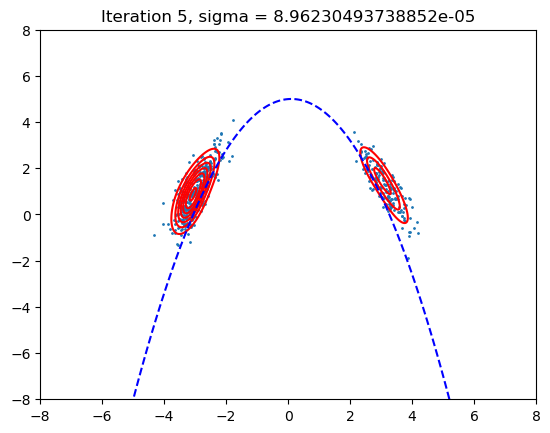

Converged after 5 iterations.
Failure probability estimated by iCE-NGM: 0.003034766603835748
Relative error: 0.006050226100490743


In [5]:
""" 2.3 Solve the problem with iCE-NGM and fixed stopping criteria. """
ice_ngm = ImprovedCEAISNonparametricGaussianMixture(limit_state_func=limit_state_func, input_density=input_density)
# for NGM, delta_target is set to 0.6 since it is achievable.
ice_ngm.fit(max_iter=100, samples_per_level=500, delta_target=0.6, plot_process=True)
# predict the failure probability with N=3000 samples.
pf_ngm = ice_ngm.predict(N=3000)
print(f"Failure probability estimated by iCE-NGM: {pf_ngm}")
print(f"Relative error: {(pf_ngm - pf_true) / pf_true}")

## iCE-SG with budget-informed stopping criteria

Failure probability estimated by iCE-SG with budget-informed stopping criteria: 0.003136732818157989
Relative error: 0.039852869389053164


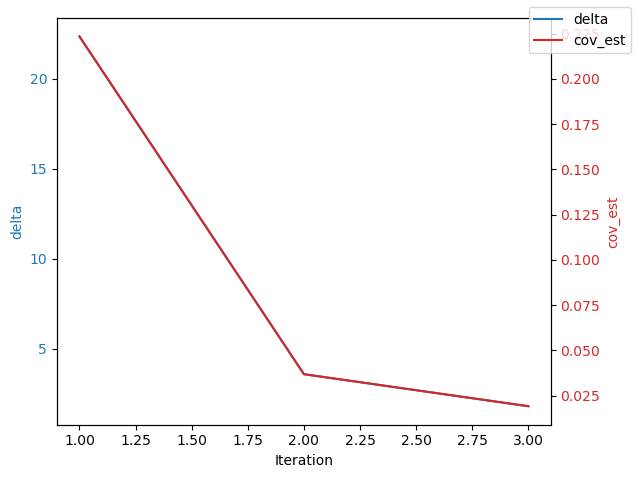

In [9]:
""" 3.1 Solve the problem with iCE-SG and budget-informed stopping criteria. """
ice_sg_budget = ImprovedCEAISSingleGaussian(limit_state_func=limit_state_func, input_density=input_density)
ice_sg_budget.fit_with_budget(max_iter=100, samples_per_level=500, sample_budget=int(1e4), plot_process=False,
                              delta_target=0, delta_upper_bound=2.0)
pf_sg_budget = ice_sg_budget.predict_with_budget()
print(f"Failure probability estimated by iCE-SG with budget-informed stopping criteria: {pf_sg_budget}")
print(f"Relative error: {(pf_sg_budget - pf_true) / pf_true}")
# plot the convergence process.
ice_sg_budget.plot_convergence()

## iCE-KDE with budget-informed stopping criteria

Failure probability estimated by iCE-KDE with budget-informed stopping criteria: 0.0029528759140478116
Relative error: -0.02109721478427043


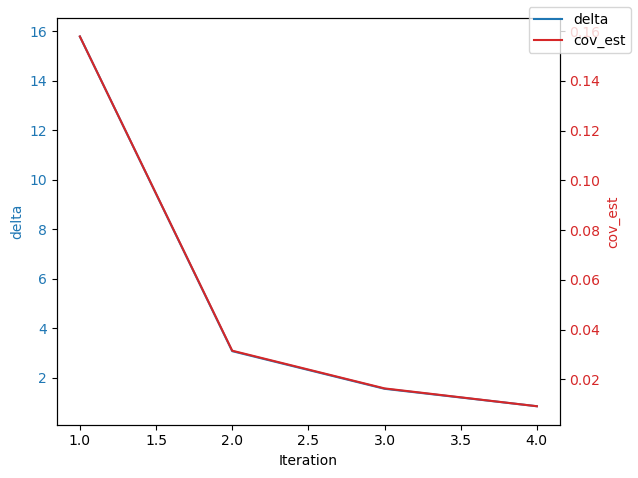

In [10]:
""" 3.2 Solve the problem with iCE-KDE and budget-informed stopping criteria. """
ice_kde_budget = ImprovedCEAISKernelDensityEstimation(limit_state_func=limit_state_func, input_density=input_density)
ice_kde_budget.fit_with_budget(max_iter=100, samples_per_level=500, sample_budget=int(1e4), plot_process=False,
                               delta_target=0, delta_upper_bound=1)
pf_kde_budget = ice_kde_budget.predict_with_budget()
print(f"Failure probability estimated by iCE-KDE with budget-informed stopping criteria: {pf_kde_budget}")
print(f"Relative error: {(pf_kde_budget - pf_true) / pf_true}")
# plot the convergence process.
ice_kde_budget.plot_convergence()

## iCE-NGM with budget-informed stopping criteria

Failure probability estimated by iCE-NGM with budget-informed stopping criteria: 0.002996657957012497
Relative error: -0.006583105472506389


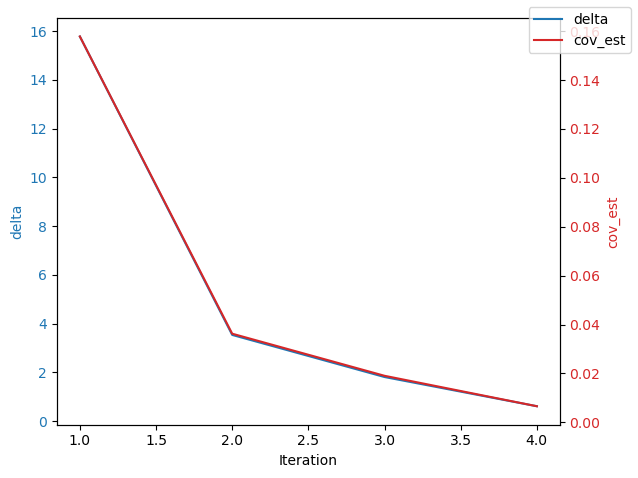

In [11]:
""" 3.3 Solve the problem with iCE-NGM and budget-informed stopping criteria. """
ice_ngm_budget = ImprovedCEAISNonparametricGaussianMixture(limit_state_func=limit_state_func, input_density=input_density)
ice_ngm_budget.fit_with_budget(max_iter=100, samples_per_level=500, sample_budget=int(1e4), plot_process=False,
                               delta_target=0, delta_upper_bound=1)
pf_ngm_budget = ice_ngm_budget.predict_with_budget()
print(f"Failure probability estimated by iCE-NGM with budget-informed stopping criteria: {pf_ngm_budget}")
print(f"Relative error: {(pf_ngm_budget - pf_true) / pf_true}")
# plot the convergence process.
ice_ngm_budget.plot_convergence()